# Lab 14 Template              

Proving that the SNe data is consistent with the BenchMark Cosmology.


Before we get started, let's execute the following cell which is almost always needed for our notebooks:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.constants import c

# Importing the solutions from Lab 13
from Lab13_Soln import CosmologicalTools

In [2]:

# Define the benchmark cosmology at z =0
# Planck 2016 results. XIII. Cosmological parameters   
# Planck Collaboration+2016 A&A 594 13  Table 4, column 2 

OmegaM0_planck = 0.308   # Matter Density Parameter
OmegaR0_planck = 8.24e-5  # Radiation Density Parameter
OmegaL0_planck = 0.692  # Dark Energy Density Parameter
h_planck = 0.6781   # Hubble Constant  100 h km/s/Mpc


In [3]:
# Define the Einstein-DeSitter cosmology (Matter Dominated)
OmegaMD = 1
OmegaRD = 0
OmegaLD = 0
# h is the same = h_planck

In [4]:
# Initialize Instances of the Cosmological Tools Class. 
BenchMark = CosmologicalTools(OmegaM0_planck,OmegaR0_planck,OmegaL0_planck,h_planck)
EinsteinDeSitter = CosmologicalTools(OmegaMD,OmegaRD,OmegaLD,h_planck)



In this exercise we will use data from the Supernova Cosmology project, one of the two teams which first found that the expansion rate of the Universe is accelerating in 1999. A simple introduction to the methods and findings of the SCP group can be found at https://newscenter.lbl.gov/2009/10/27/evolving-dark-energy/. The original paper is Perlmutter *et al.* 1999, "Measurement of $\Omega$ and $\Lambda$ from 42 High Redshift Supernovae", The Astrophysical Journal, Vol. 517, page 565.

The data set we will be using is a more recent sample, containing observations of 580 supernovae, known as the Union 2.1 sample from the paper Suzuki *et al*. 2012, "THE *HUBBLE SPACE TELESCOPE* CLUSTER SUPERNOVA SURVEY. V. IMPROVING THE DARK-ENERGY CONSTRAINTS ABOVE $z>1$ AND BUILDING AN EARLY-TYPE-HOSTED SUPERNOVA SAMPLE", The Astrophysical Journal, vol. 746, page 85.

The data are in the file SNeData.txt.

Take a look at the file using the `with` statement. 

One should always close files when finished using them.
The `with` statement makes this automatic.

Lets simply open the file and print out the first 10 lines to see how the file is formatted:

In [5]:
with open('SNeData.txt', 'r') as infile:
    for i in range(10):
        line = infile.readline()
        line = line.rstrip("\n")
        print(line)

# Supernova Cosmology Project Union2.1 Data
#  Suzuki et al. 
#Name z DistMod DistModErr ProbLowMassHost
1993ah 0.028488        35.3465833928 0.223905932998  0.128418942246
1993ag 0.050043        36.6823679154 0.166828851413  0.128418942246
1993o  0.052926        36.8176912545 0.1557559148    0.128418942246
1993b  0.070086        37.4467365424 0.158466934433  0.128418942246
1992bs 0.062668        37.4834093505 0.156099434739  0.128418942246
1992br 0.087589        38.2290570494 0.187745679272  0.128418942246
1992bp 0.078577        37.4881622607 0.155635656185  0.128418942246


The top of any good data file intended for sharing with others contains a "header" -- some lines at the top which describe the contents of the file.

Here we see that the file contains the SCP Union2.1 data, and that the columns are:

 * the name of the supernova
 * the redshift measured from its spectrum
 * its distance modulus
 * an estimate of the measurement error in the distance modulus
 * the probability the supernova occurred in a low-mass host galaxy
 


# Part A

The difference between the absolute magnitude $M$ and the apparent magnitude $m$, a number called the *distance modulus* which depends only upon the distance to the source

$$
\begin{split}
m-M &= - 2.5 \log_{10} \left(\frac{1}{F_0}\frac{L}{4\pi d^2}\right) + 2.5 \log_{10}\left(\frac{1}{F_0}\frac{L}{4\pi(10\ \textrm{pc})^2}\right)  \\
&= 5 \log_{10}\left(\frac{d}{10\ \textrm{pc}}\right)
\end{split}
$$
Because $M$ and $m$ are logarithmic functions, their difference is proportional to the *ratio* of the distance $d$ to 10 pc.

This is the distance measurement given in the data file for the distance to the supernovae. The measured LUMINOSITY distance is then

$$ d_L = 10^{(m-M)/5 +1} \textrm{pc} $$

In [30]:
def Distance_fromMod(mod):

    """ Function to compute the distance using the distance modulus
    PARAMETERS
    ----------
    mod: `float`
        distance modulus (apparent magnitude - absolute magnitude)

    OUTPUTS
    -------
    DL: `float`
        luminiosity distance in Mpc
    """
    
    DL = 10**(mod/5 + 1)  # Luminosity distance in pc
    DL = DL/1e6 # Convert to Mpc
    
    return DL

In [31]:
# Read the file in and store the values using `npgenfromtxt`
SNe_data = np.genfromtxt('SNeData.txt')

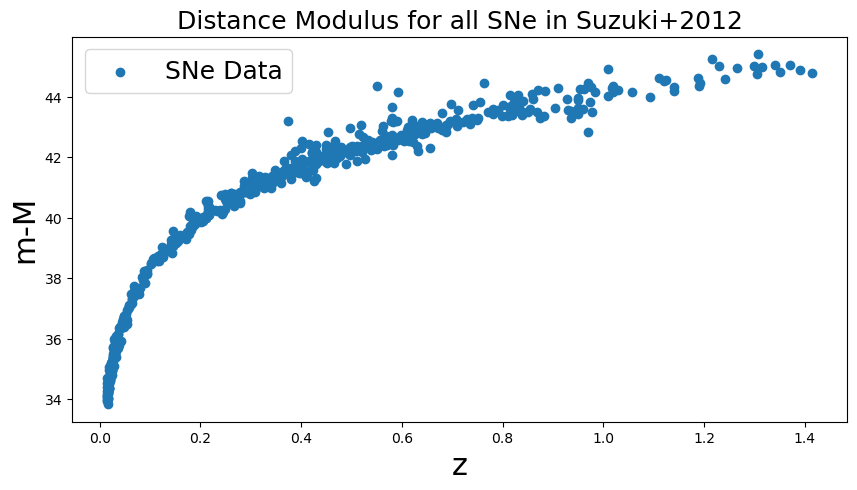

In [32]:
# Create a plot of Distance Modulus Vs. Redshift
# This is Figure 4 of Suzuki et al. 

fig = plt.figure(figsize=(10,5))
ax = plt.subplot(111)

# plot here
ax.scatter(SNe_data[:,1], SNe_data[:,2], label='SNe Data')

ax.set_xlabel('z', fontsize=22)
ax.set_ylabel('m-M', fontsize=22)
ax.set_title('Distance Modulus for all SNe in Suzuki+2012', fontsize=18)

legend = ax.legend(loc='upper left',fontsize=18)


# Part B

For each SNe in the data file compute: 

1) the luminosity distance, using from the distance modulus;

and

2) the recessional velocity in km/second, computed from the redshift using the relativistic doppler shift at low speeds, where v << c. 

$1+z = \frac{\lambda_{\rm obs}}{\lambda_{\rm e}}$

$z = \frac{\Delta \lambda}{\lambda_{\rm e}} = \frac{v}{c}$

In [33]:
#1) Distance
# Use Distance Modulus to determine the luminosity distance to each supernova
SNe_DL = Distance_fromMod(SNe_data[:,2])

In [73]:
#2) Velocity
# Determine the recessional speed based on the redshift
SNe_v = SNe_data[:,1] * c.to('km/s')

# Part C

Plot distance versus velocity just for the "nearby" supernovae, those within 200 Mpc of Earth. We can select the set of indices of the nearby supernovae using the `numpy.where` function

In [75]:
# Create an index for the nearby supernovae
nearby = np.where(SNe_DL < 200)[0]

In [76]:
# store the number of nearby supernovae
nNear = len(nearby)

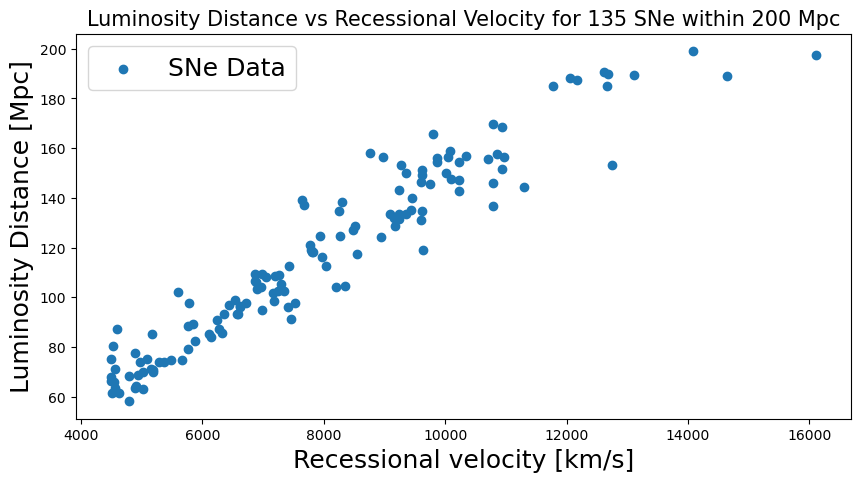

In [77]:
# Plot the Luminosity Distance vs. Recessional Speed for all nearby Supernovae

fig = plt.figure(figsize=(10,5))
ax = plt.subplot(111)

# plot nearby SNe
ax.scatter(SNe_v[nearby], SNe_DL[nearby], label='SNe Data')

ax.set_xlabel('Recessional velocity [km/s]', fontsize=18)
ax.set_ylabel('Luminosity Distance [Mpc]', fontsize=18)
ax.set_title(f"Luminosity Distance vs Recessional Velocity for {nNear} SNe within 200 Mpc",
             fontsize=15)

legend = ax.legend(loc='upper left',fontsize=18)


# Part D

Add a linear model atop the data, using Hubble's Law

 V = Hubble Parameter today * Comoving Radial Distance = H$_o$ D$_c$

In [234]:
# Create a linear model

def LinearModel(min_DC, max_DC):
    """
    Constructs linear model of recession velocities based on Hubble's law
    
    Inputs:
        min_DC (float): minimum comoving distance to consider in Mpc
        max_DC (float): maximum comoving distance to consider in 
        
    Returns:
        V_Hubble (numpy array): Recession velocities in km/s according to Hubble constant today
    """
    
    SNe_DC = np.linspace(min_DC, max_DC) # Create comoving distance array
    V_Hubble = BenchMark.HubbleParameter(0).value * SNe_DC # Compute recession velocities according to Hubble's law
    
    return V_Hubble, SNe_DC

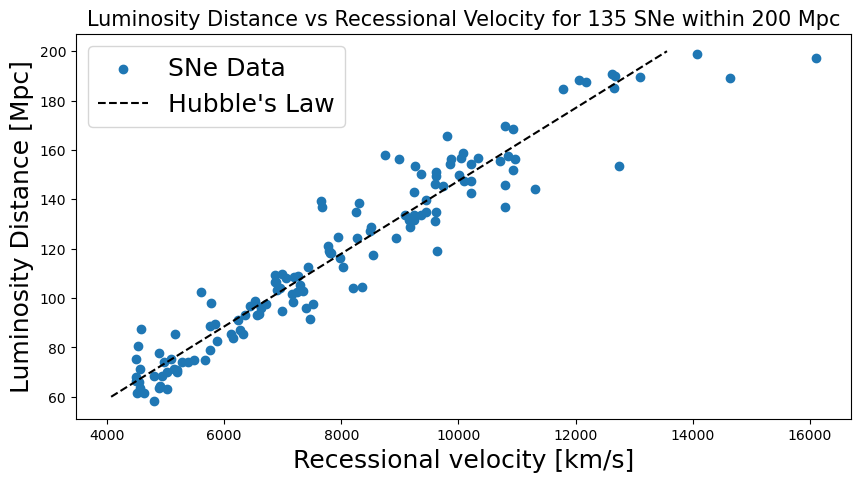

In [235]:
# Add the linear model to the figure of the nearest SNe

V_Hubble_nearby, SNe_DC_nearby = LinearModel(60, 200) # Stop at 200 Mpc

fig = plt.figure(figsize=(10,5))
ax = plt.subplot(111)

ax.scatter(SNe_v[nearby], SNe_DL[nearby], label='SNe Data')
ax.plot(V_Hubble_nearby, SNe_DC_nearby, c='k', linestyle='--', label="Hubble's Law")

ax.set_xlabel('Recessional velocity [km/s]', fontsize=18)
ax.set_ylabel('Luminosity Distance [Mpc]', fontsize=18)
ax.set_title(f"Luminosity Distance vs Recessional Velocity for {nNear} SNe within 200 Mpc",
             fontsize=15)

legend = ax.legend(loc='upper left',fontsize=18)

# Part E
Let's now try plotting the whole dataset, which extends to distances far beyond what Hubble could have measured in his day

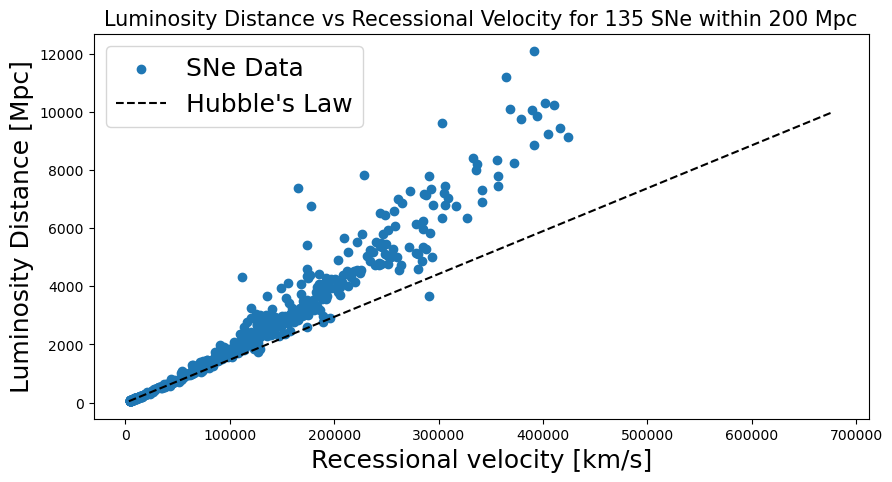

In [236]:
# Plot the whole dataset, not just the nearby SNe

V_Hubble_all, SNe_DC_all = LinearModel(50, 10000) # Stop at maximum luminosity distance of SNe, around 10000 Mpc


fig = plt.figure(figsize=(10,5))
ax = plt.subplot(111)

ax.scatter(SNe_v, SNe_DL, label='SNe Data')
ax.plot(V_Hubble_all, SNe_DC_all, c='k', linestyle='--', label="Hubble's Law")

ax.set_xlabel('Recessional velocity [km/s]', fontsize=18)
ax.set_ylabel('Luminosity Distance [Mpc]', fontsize=18)
ax.set_title(f"Luminosity Distance vs Recessional Velocity for {nNear} SNe within 200 Mpc",
             fontsize=15)

legend = ax.legend(loc='upper left',fontsize=18)

The distant supernovae are moving more slowly than a constant Ho would predict...

 note that you could import `LambdaCDM` object from `astropy.cosmology` (CDM is "cold dark matter")

`from astropy.cosmology import LambdaCDM`

But instead we're going to use our own code ! 

# Part F

Instead of assuming a linear model, let's use our code to compute a model for the luminosity distance to objects moving with the Hubble flow. 

In [237]:
# define an array of redshifts to compute the luminosity distance
z_range = np.linspace(0.001, 1.5)

In [238]:
# Compute the corresponding recessional velocities using the doppler shift
# z = v/c
Recession_V = z_range * c.to('km/s')

In [239]:
# Generate models for the luminosity distance as a function of z 
# for Benchmark and Einstein De Sitter Cosmologies. 
# Use a list comprehension

BenchMark_DL = np.array([BenchMark.LuminosityDistance(ze).value for ze in z_range])
DeSitter_DL = np.array([EinsteinDeSitter.LuminosityDistance(ze).value for ze in z_range])

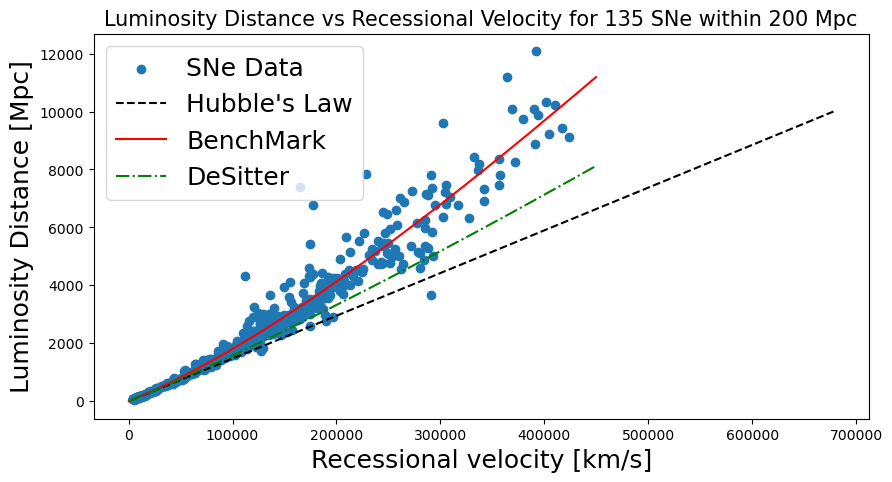

In [240]:
# Plot the new models on top of the data


fig = plt.figure(figsize=(10,5))
ax = plt.subplot(111)

ax.scatter(SNe_v, SNe_DL, label='SNe Data')
ax.plot(V_Hubble_all, SNe_DC_all, c='k', linestyle='--', label="Hubble's Law")
ax.plot(Recession_V, BenchMark_DL, c='r', label='BenchMark')
ax.plot(Recession_V, DeSitter_DL, c='g', linestyle='-.', label='DeSitter')

ax.set_xlabel('Recessional velocity [km/s]', fontsize=18)
ax.set_ylabel('Luminosity Distance [Mpc]', fontsize=18)
ax.set_title(f"Luminosity Distance vs Recessional Velocity for {nNear} SNe within 200 Mpc",
             fontsize=15)

legend = ax.legend(loc='upper left',fontsize=18)


To determine the best fit, you would test different values of Omega_M and Omega_L and generate probability contours

![title](scp2.1.png)

